
# 02 — Baseline Model: Logistic Regression + LightGBM

Notebook **2 of 4**. Builds a standard tabular baseline for IEEE-CIS fraud detection, with lightweight
feature engineering (no graph, no Vesta V-column deep-dive — that's notebook 3's job). This is the number
[04_gcn_model.ipynb](04_gcn_model.ipynb) needs to beat.

Uses `fraud_utils.time_based_split` for the train/valid split so that notebook 4's GCN is evaluated on
**exactly the same rows** — otherwise "GCN beats baseline" isn't a meaningful claim.

Requires: `pip install scikit-learn lightgbm` (falls back to `sklearn.ensemble.HistGradientBoostingClassifier`
if `lightgbm` isn't installed).


In [1]:
import sys, pathlib, time
sys.path.append(str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_recall_curve, confusion_matrix, classification_report)

try:
    from lightgbm import LGBMClassifier, early_stopping as lgb_early_stopping
    HAS_LIGHTGBM = True
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAS_LIGHTGBM = False
    print("lightgbm not installed -> falling back to sklearn's HistGradientBoostingClassifier "
          "(similar histogram-based GBM, but no early stopping on a held-out eval set).")

from fraud_utils import (RANDOM_SEED, set_seed, load_raw_data, time_based_split,
                          save_metrics, save_predictions)

set_seed()
pd.options.display.max_columns = 100
plt.rcParams["figure.figsize"] = (7, 5)
%matplotlib inline


lightgbm not installed -> falling back to sklearn's HistGradientBoostingClassifier (similar histogram-based GBM, but no early stopping on a held-out eval set).


## 1. Load & Merge Data

In [2]:
train, test = load_raw_data()


Loading train_transaction.csv ...
Loading train_identity.csv ...
Loading test_transaction.csv ...
Loading test_identity.csv ...
Reducing memory usage...
  Memory: 2514.0 MB -> 1603.3 MB (36% reduction)
  Memory: 2164.1 MB -> 1386.1 MB (36% reduction)
train: (590540, 434), test: (506691, 433), fraud rate: 0.0350


## 2. Time-Based Train/Validation Split

As shown in [01_eda.ipynb](01_eda.ipynb) §5, the real Kaggle test set is entirely *after* train in time.
We reproduce that gap locally: sort by `TransactionDT`, hold out the last 20% as validation. This is the
**same split notebooks 3 and 4 use** (via `fraud_utils.time_based_split`, seeded/parameterized identically).


train: 472,432 rows (fraud rate 0.0351)
valid: 118,108 rows (fraud rate 0.0344)


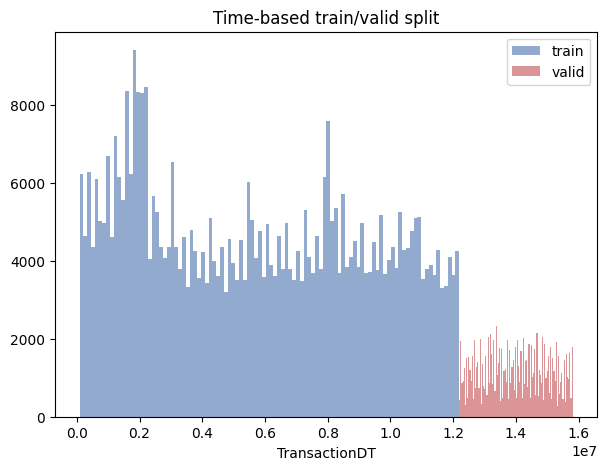

In [3]:
train_mask, valid_mask = time_based_split(train)
print(f"train: {train_mask.sum():,} rows (fraud rate {train.loc[train_mask, 'isFraud'].mean():.4f})")
print(f"valid: {valid_mask.sum():,} rows (fraud rate {train.loc[valid_mask, 'isFraud'].mean():.4f})")

fig, ax = plt.subplots()
ax.hist(train.loc[train_mask, "TransactionDT"], bins=100, alpha=0.6, label="train", color="#4C72B0")
ax.hist(train.loc[valid_mask, "TransactionDT"], bins=100, alpha=0.6, label="valid", color="#C44E52")
ax.set_xlabel("TransactionDT")
ax.legend()
ax.set_title("Time-based train/valid split")
plt.show()


## 3. Baseline Feature Engineering (lightweight)

Deliberately simple — frequency-encode a few high-cardinality identifiers, label-encode low-cardinality
categoricals, keep `C`/`D` numeric as-is, and **skip** the V-column variance selection / card z-scores /
graph edges that notebook 3 builds for the GNN. This is what a data scientist would build first, in an
afternoon, before reaching for anything more elaborate.


In [4]:
def engineer_baseline_features(df, freq_maps=None, cat_maps=None, fit=True):
    df = df.copy()
    df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])
    df["Transaction_hour"] = ((df["TransactionDT"] / 3600) % 24).astype(int)
    df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)).astype(int)
    df["Transaction_dow"] = df["Transaction_day"] % 7

    freq_cols = ["card1", "addr1", "P_emaildomain"]
    cat_cols = ["ProductCD", "card4", "card6", "DeviceType"] + [f"M{i}" for i in range(1, 10)]

    if fit:
        freq_maps = {c: df[c].value_counts(dropna=False) for c in freq_cols}
        cat_maps = {c: {v: i for i, v in enumerate(df[c].astype("category").cat.categories)} for c in cat_cols}

    for c in freq_cols:
        df[f"{c}_freq"] = df[c].map(freq_maps[c]).fillna(0)
    for c in cat_cols:
        df[f"{c}_enc"] = df[c].map(cat_maps[c]).fillna(-1)

    c_cols = [c for c in df.columns if c.startswith("C") and c[1:].isdigit()]
    d_cols = [c for c in df.columns if c.startswith("D") and c[1:].isdigit()]

    feature_cols = (["TransactionAmt", "TransactionAmt_log", "Transaction_hour",
                      "Transaction_day", "Transaction_dow"]
                     + [f"{c}_freq" for c in freq_cols] + [f"{c}_enc" for c in cat_cols]
                     + c_cols + d_cols)
    feature_cols = [c for c in feature_cols if c in df.columns]

    X = df[feature_cols].fillna(-999)
    return X, feature_cols, freq_maps, cat_maps


X_all, feature_cols, freq_maps, cat_maps = engineer_baseline_features(train, fit=True)
y_all = train["isFraud"].values
print(f"{len(feature_cols)} baseline features: {feature_cols}")

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_valid, y_valid = X_all[valid_mask], y_all[valid_mask]
print(f"X_train: {X_train.shape}   X_valid: {X_valid.shape}")


50 baseline features: ['TransactionAmt', 'TransactionAmt_log', 'Transaction_hour', 'Transaction_day', 'Transaction_dow', 'card1_freq', 'addr1_freq', 'P_emaildomain_freq', 'ProductCD_enc', 'card4_enc', 'card6_enc', 'DeviceType_enc', 'M1_enc', 'M2_enc', 'M3_enc', 'M4_enc', 'M5_enc', 'M6_enc', 'M7_enc', 'M8_enc', 'M9_enc', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']
X_train: (472432, 50)   X_valid: (118108, 50)


## 4. Model 1 — Logistic Regression (simple baseline)

In [5]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)),
])

t0 = time.time()
logreg.fit(X_train, y_train)
logreg_valid_scores = logreg.predict_proba(X_valid)[:, 1]
logreg_auc = roc_auc_score(y_valid, logreg_valid_scores)
logreg_ap = average_precision_score(y_valid, logreg_valid_scores)
print(f"LogisticRegression  |  valid AUC: {logreg_auc:.4f}  |  valid PR-AUC: {logreg_ap:.4f}  "
      f"|  {time.time() - t0:.1f}s")


LogisticRegression  |  valid AUC: 0.8052  |  valid PR-AUC: 0.2126  |  31.2s


## 5. Model 2 — LightGBM (strong tabular baseline)

In [6]:
t0 = time.time()
if HAS_LIGHTGBM:
    lgbm = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[lgb_early_stopping(100, verbose=False)],
    )
    gbm_valid_scores = lgbm.predict_proba(X_valid)[:, 1]
    importances = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
else:
    lgbm = HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.05, max_leaf_nodes=63,
        class_weight="balanced", random_state=RANDOM_SEED,
    )
    lgbm.fit(X_train, y_train)
    gbm_valid_scores = lgbm.predict_proba(X_valid)[:, 1]
    importances = None

gbm_auc = roc_auc_score(y_valid, gbm_valid_scores)
gbm_ap = average_precision_score(y_valid, gbm_valid_scores)
gbm_name = "LightGBM" if HAS_LIGHTGBM else "HistGradientBoosting"
print(f"{gbm_name}  |  valid AUC: {gbm_auc:.4f}  |  valid PR-AUC: {gbm_ap:.4f}  |  {time.time() - t0:.1f}s")

if importances is not None:
    importances.head(20).sort_values().plot(kind="barh", color="#55A868")
    plt.title(f"{gbm_name} — top-20 feature importances")
    plt.show()


HistGradientBoosting  |  valid AUC: 0.9123  |  valid PR-AUC: 0.4878  |  58.4s


## 6. Evaluation

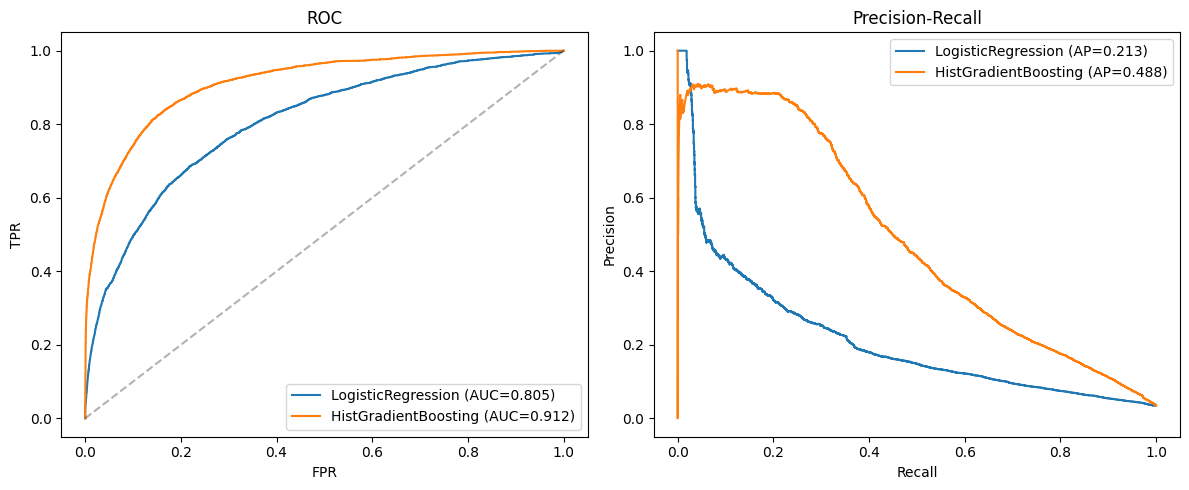

--- HistGradientBoosting classification report @ threshold 0.5 ---
              precision    recall  f1-score   support

           0     0.9833    0.9698    0.9765    114044
           1     0.3889    0.5389    0.4518      4064

    accuracy                         0.9550    118108
   macro avg     0.6861    0.7544    0.7142    118108
weighted avg     0.9629    0.9550    0.9585    118108

[[110603   3441]
 [  1874   2190]]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, scores in [("LogisticRegression", logreg_valid_scores), (gbm_name, gbm_valid_scores)]:
    fpr, tpr, _ = roc_curve(y_valid, scores)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_valid, scores):.3f})")
    prec, rec, _ = precision_recall_curve(y_valid, scores)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_valid, scores):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall"); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"--- {gbm_name} classification report @ threshold 0.5 ---")
print(classification_report(y_valid, (gbm_valid_scores > 0.5).astype(int), digits=4))
print(confusion_matrix(y_valid, (gbm_valid_scores > 0.5).astype(int)))


## 7. Save Results for Comparison

Notebook 4 loads these files to build the final GCN-vs-baseline comparison table/plots.


In [8]:
save_metrics("baseline_logreg", {
    "model": "LogisticRegression",
    "auc": logreg_auc,
    "pr_auc": logreg_ap,
    "n_train": int(len(X_train)),
    "n_valid": int(len(X_valid)),
    "n_features": len(feature_cols),
})
save_predictions("baseline_logreg", y_valid, logreg_valid_scores)

save_metrics("baseline_lightgbm", {
    "model": gbm_name,
    "auc": gbm_auc,
    "pr_auc": gbm_ap,
    "n_train": int(len(X_train)),
    "n_valid": int(len(X_valid)),
    "n_features": len(feature_cols),
})
save_predictions("baseline_lightgbm", y_valid, gbm_valid_scores)


Saved metrics -> /Users/srimugunthan/Documents/gitrepos/Transaction-fraud-GNN/results/baseline_logreg_metrics.json
Saved predictions -> /Users/srimugunthan/Documents/gitrepos/Transaction-fraud-GNN/results/baseline_logreg_preds.npz
Saved metrics -> /Users/srimugunthan/Documents/gitrepos/Transaction-fraud-GNN/results/baseline_lightgbm_metrics.json
Saved predictions -> /Users/srimugunthan/Documents/gitrepos/Transaction-fraud-GNN/results/baseline_lightgbm_preds.npz


PosixPath('/Users/srimugunthan/Documents/gitrepos/Transaction-fraud-GNN/results/baseline_lightgbm_preds.npz')

## Summary

| Model | Valid AUC | Valid PR-AUC |
|---|---|---|
| Logistic Regression | see output above | see output above |
| LightGBM / HistGBM | see output above | see output above |

The GBM number is the one to watch — GBMs are traditionally very strong on this dataset (published solutions
reach ~0.96 AUC with heavy feature engineering + ensembling). The GCN in notebook 4 aims to match or beat it,
or at least add complementary signal from shared-infrastructure graph structure that a purely tabular model
can't see row-by-row.

**Next**: [03_preprocessing_gnn_features.ipynb](03_preprocessing_gnn_features.ipynb) builds the richer feature
set + graph edges needed for the GCN.
